<a href="https://colab.research.google.com/github/dewzpruth/genaiexps/blob/main/genai6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 493kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.56MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.41MB/s]


Starting VAE training...
Epoch [1/20], Loss: 23096.0975
Epoch [2/20], Loss: 20357.7229
Epoch [3/20], Loss: 19680.2089
Epoch [4/20], Loss: 19294.6220
Epoch [5/20], Loss: 19029.2986
Epoch [6/20], Loss: 18823.0449
Epoch [7/20], Loss: 18666.4368
Epoch [8/20], Loss: 18543.9646
Epoch [9/20], Loss: 18415.8729
Epoch [10/20], Loss: 18328.7968
Epoch [11/20], Loss: 18247.1964
Epoch [12/20], Loss: 18184.0492
Epoch [13/20], Loss: 18122.3296
Epoch [14/20], Loss: 18070.4257
Epoch [15/20], Loss: 18014.2459
Epoch [16/20], Loss: 17967.4490
Epoch [17/20], Loss: 17915.7842
Epoch [18/20], Loss: 17874.1024
Epoch [19/20], Loss: 17827.1393
Epoch [20/20], Loss: 17838.7382
Training completed!

Visualizing Original vs Reconstructed Images + 2D Latent Space...


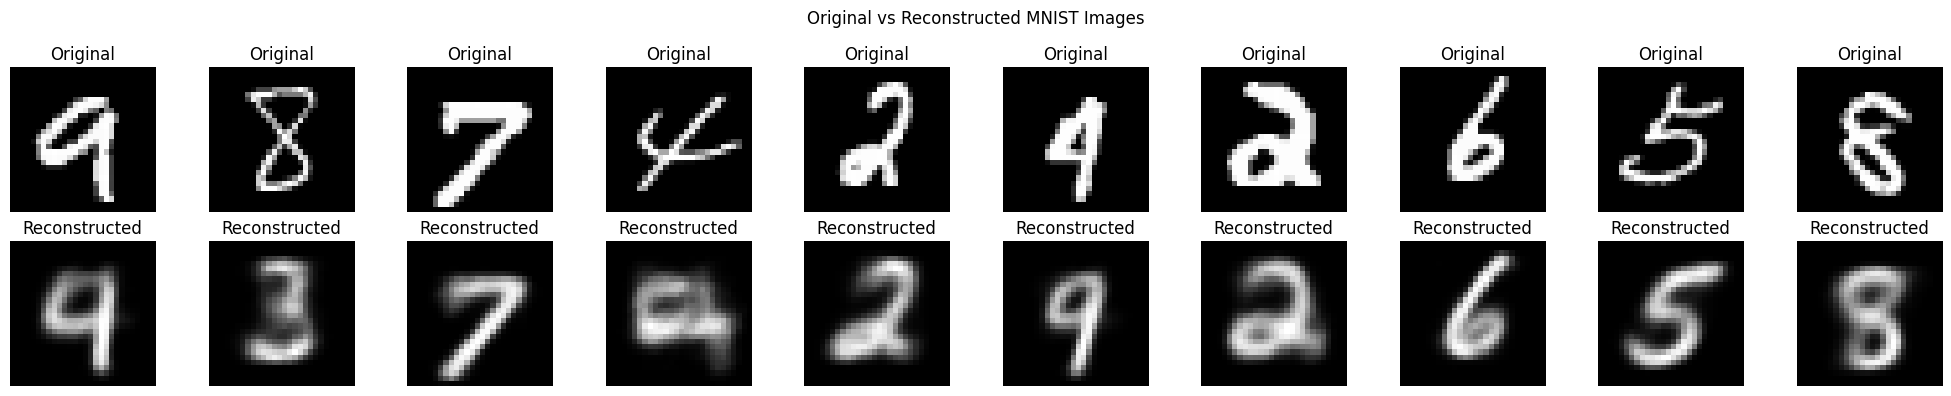

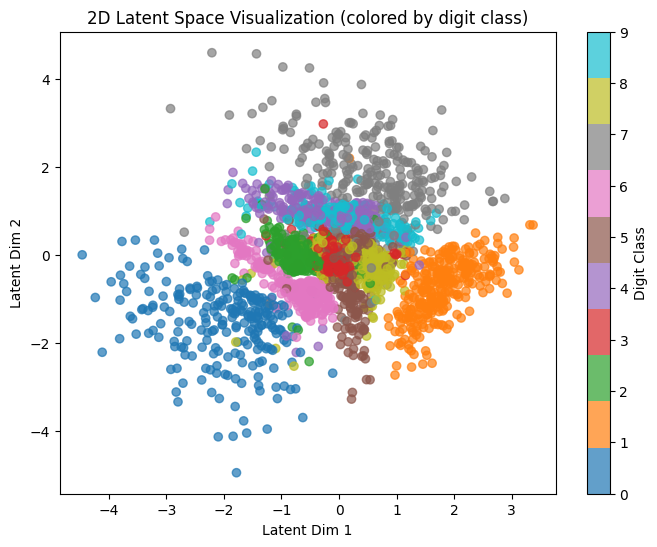

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
# Reproducibility
torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
latent_dim = 2 # 2D for easy visualization
batch_size = 128
num_epochs = 20
# Small standard MNIST dataset (no huge dataset used)
transform = transforms.Compose([transforms.ToTensor()])
train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
class VAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(nn.Flatten(),
                                     nn.Linear(784, 512), nn.ReLU(), nn.Linear(512, 256), nn.ReLU())
        self.fc_mu = nn.Linear(256, latent_dim)
        self.fc_logvar = nn.Linear(256, latent_dim)
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 256), nn.ReLU(),
            nn.Linear(256, 512), nn.ReLU(),
            nn.Linear(512, 784), nn.Sigmoid())

    def reparameterize(self, mu, logvar):
        return mu + torch.exp(0.5*logvar) * torch.randn_like(mu)

    def forward(self, x):
        h = self.encoder(x)
        mu, logvar = self.fc_mu(h), self.fc_logvar(h)
        z = self.reparameterize(mu, logvar)
        return self.decoder(z), mu, logvar

def vae_loss(recon_x, x, mu, logvar):
    BCE = nn.functional.binary_cross_entropy(recon_x, x.view(-1,784), reduction='sum')
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return BCE + KLD

model = VAE().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("Starting VAE training...")
for epoch in range(num_epochs):
    total_loss = 0
    for data in train_loader:
        img = data[0].to(device)
        recon, mu, logvar = model(img)
        loss = vae_loss(recon, img, mu, logvar)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {total_loss/len(train_loader):.4f}')
print("Training completed!")

# === SHOW IMAGES + LATENT SPACE (as per your requirement) ===
print("\nVisualizing Original vs Reconstructed Images + 2D Latent Space...")
model.eval()
with torch.no_grad():
    test_images, labels = next(iter(train_loader))
    test_images = test_images[:10].to(device)
    recon_images, mu, _ = model(test_images)

# Original vs Reconstructed
fig, axes = plt.subplots(2, 10, figsize=(20, 4))
for i in range(10):
    orig = test_images[i].cpu().view(28, 28).numpy()
    axes[0, i].imshow(orig, cmap='gray')
    axes[0, i].axis('off')
    axes[0, i].set_title("Original")

    recon = recon_images[i].cpu().view(28, 28).numpy()
    axes[1, i].imshow(recon, cmap='gray')
    axes[1, i].axis('off')
    axes[1, i].set_title("Reconstructed")
plt.suptitle("Original vs Reconstructed MNIST Images")
plt.tight_layout()

plt.show()

# Latent Space Visualization
all_mu = []
all_labels = []
with torch.no_grad():
    for data, lbl in train_loader:
        _, mu, _ = model(data.to(device))
        all_mu.append(mu.cpu())
        all_labels.extend(lbl.numpy())
        if len(all_mu) > 20: break # small sample for plot

all_mu = torch.cat(all_mu)
plt.figure(figsize=(8, 6))
scatter = plt.scatter(all_mu[:, 0], all_mu[:, 1], c=all_labels, cmap='tab10', alpha=0.7)
plt.colorbar(scatter, label='Digit Class')
plt.title("2D Latent Space Visualization (colored by digit class)")
plt.xlabel("Latent Dim 1")
plt.ylabel("Latent Dim 2")
plt.show()